In [58]:
import pandas as pd
import json
import numpy as np
import requests
from tqdm.auto import tqdm
from config import URL, TOKEN

In [59]:
headers = {
    "Authorization": f"Bearer {TOKEN}"
}

itemCount = np.inf
data = {"entries": []}

offset = 0
steps = 1000

progress = None

while len(data["entries"]) < itemCount:

    response = requests.get(
        f"{URL}person/client/query?limit={steps}&offset={offset}",
        headers=headers
    )

    if response.status_code == 200:
        responseData = response.json()

        entries = responseData["entries"]

        # Total becomes known after first request
        if progress is None:
            itemCount = responseData["pagingInfo"]["itemCount"]

            progress = tqdm(
                total=itemCount,
                desc="Downloading clients",
                unit="entries"
            )

        data["entries"].extend(entries)

        # Advance by actual number received
        progress.update(len(entries))

        offset += steps

    else:
        print(response.json())
        break

if progress is not None:
    progress.close()

In [70]:
exceptions = [
	"metadata",
	"locality",
	"postalcode",
	"contactoptions",
	"personFullName",
	"personFullNameNoTitle",
	"tenantid",
	"persontype",
	"adresse",
	"mailAddressing",
	"socialInsuranceNumber",
	"comments",
	"givenName",
	"familyName",
	"primaryEmailAddress",
	'addresses',
	'primaryPhoneNumber',
	'address',
	'residentialAddress',
	'address',
	'geoLocation',
	'billingAddress',
	'serviceAddress',
	'legalAddress',
	'businessAddress',
	'emailAddresses',
	'phoneNumbers',
	'personFullNameNoTitle',
	'personFullName',
	'mailAddressing',
	'postalAddress',
	'contractualAddressing',
	'caatsDateOfBirth',
	'gender',
	'locations',
	'bankDetails',
	'personStatus',
	"chapterId",
	"language",
	"ordinal",
	"sectionId",
	"academicTitlePrefix",
	"personNr",
	"content",
	"consecutiveNumber",
	'Klient:innen_Empfohlen_Ja',
	'Klient:innen_Erstrkontakt_erfassen_Ja',
	'Klient:innen_Bew_Ein_Ja',
	'abrech-akonto',
	'abrech-buerge-hinterlegt',
	'pers-visite-keine',
	'medizinische-delegation-hochgeladen',
	'medizinische-delegation-nicht-notwendig',
	'Klient:innen_Medizinische_Delegation_Ja',
	'pflegerische-delegation-hochgeladen',
	'pflegerische-delegation-nicht-notwendig',
	'Klient:innen_Pflegerische_Delegation_JA',
	"admin-beruf",
	'pflegevisite-letzte-date',
	'pflegevisite-letzte-dgkp',
	'pflegerisch-person',
	'erstkontakt-bemerkung',
	"admin-kooperationspartner",
	"orgRef",
	"admin.gsber",
	"admin-bundesland"
]

exceptions = [x.lower() for x in exceptions]

In [71]:
def extractStatement(statement):
    field = {}
    if statement["statementId"].lower() in exceptions:
        return field

    match statement["answerScheme"]:
        case 1:
            field[statement["statementId"]] = statement["answerValue"]["displayText"]
        case 2:
            #do nothing
            field = {}
        case 3:
            field[statement["statementId"]] = statement["answerYesno"] == 2
        case 4:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False

        case 5:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False
        case 8:
            if "answerDateTime" in statement.keys():
                if "userLocalTime" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["userLocalTime"]
                elif "timeUtc" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["timeUtc"]
        case _:
            print(f'Found statement: {statement["answerScheme"]} - {statement["statementId"]} -  {statement}')


    return field
        

def returnEntry(entry):
    keys = entry.keys()
    finalFields = {}
    if "statementId" in keys:
        finalFields = finalFields | extractStatement(entry)
    else:
        for key in keys:
            
            if key.lower() in exceptions:
                continue
            
            typing = type(entry[key]).__name__
            match typing:
                case "str":
                    finalFields[key] = entry[key]
                    
                case "int":
                    finalFields[key] = entry[key]

                case "bool":
                    finalFields[key] = entry[key]

                case "float":
                    finalFields[key] = entry[key]
                    
                case "dict":
                    if "displayText" in entry[key].keys():
                        finalFields[key] = entry[key]["displayText"]
                        continue
                    else:
                        finalFields = finalFields | returnEntry(entry[key])
                    
                case "list":
                    for item in entry[key]:
                        if type(item).__name__ == "dict":
                            finalFields = finalFields | returnEntry(item)
                        

                case _:
                    print(typing)


    
    return finalFields

In [106]:
totalData = []

if data["entries"] is not None:
    for entry in data["entries"]:
        test = returnEntry(entry)
        totalData.append(test)
        
df = pd.DataFrame(totalData)
df

,nationalityId,genderId,id,dateOfBirth,levelOfCare,admin-zone,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,...,connected-second-person,tiere-versorgen,generalPractitioner,schlaf-nacht-aufsteg-betreuung-ja-kommentar,Klient:innen_Haushalt_Sonstiges_Ja,orgAccount,unterstuetzung-pflanzen-tiere,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja,haushalt-2pers-bewilligte-pflegestufe
0,,F,00001675-a00f-e229-7e3b-bc508a36aa0b,19370407,Pflegestufe 5,Zone 4,Demenzbetreuung,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,F,00008acf-6e75-4e45-26d3-257f4bba1b8e,19370128,Pflegestufe 6,Zone 5,Premium,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,,M,000309ca-f045-c211-f96c-ac6f21ea953c,19401103,Pflegestufe 3,Zone 5,KH-Nachversorgung,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,,kA,000f17ea-ecd8-9566-e146-f51bf62e31cb,19360329,Pflegestufe 3,Zone 4,CD Perle,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,,F,00166bbc-3c94-0298-9bed-c238c2e8bbc4,19271205,Pflegestufe 3,Zone 41,Premium,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,,F,171c02d6-9888-d4a8-2a2a-08dae1825bac,19221117,NaN,Zone 2,ZZ_Standard Plus,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11996,,F,1720ab8c-319f-62f2-62f7-64016df43028,19340721,NaN,NaN,Sonstige,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11997,,F,1722a255-2976-a3d3-b6ce-3e1db9d90981,19281206,NaN,Zone 6,KH-Nachversorgung,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11998,,M,172ae964-8e7e-502e-924f-395d1ac87bb7,19390417,Pflegestufe 4,Zone 2,Basis,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [107]:
for col in df.columns:
    non_null = df[col].dropna()

    if len(non_null) > 0 and non_null.isin([True, False]).all():
        df[col] = df[col].fillna(False).astype(bool)

bool_cols = df.select_dtypes(include=["bool", "boolean"]).columns

df[bool_cols] = df[bool_cols].fillna(False)


df = df.replace(r'^\s*$', np.nan, regex=True)

df

,nationalityId,genderId,id,dateOfBirth,levelOfCare,admin-zone,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,...,connected-second-person,tiere-versorgen,generalPractitioner,schlaf-nacht-aufsteg-betreuung-ja-kommentar,Klient:innen_Haushalt_Sonstiges_Ja,orgAccount,unterstuetzung-pflanzen-tiere,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja,haushalt-2pers-bewilligte-pflegestufe
0,NaN,F,00001675-a00f-e229-7e3b-bc508a36aa0b,19370407,Pflegestufe 5,Zone 4,Demenzbetreuung,True,False,False,...,NaN,False,NaN,NaN,False,NaN,False,False,False,NaN
1,NaN,F,00008acf-6e75-4e45-26d3-257f4bba1b8e,19370128,Pflegestufe 6,Zone 5,Premium,True,False,False,...,NaN,False,NaN,NaN,False,NaN,False,False,False,NaN
2,NaN,M,000309ca-f045-c211-f96c-ac6f21ea953c,19401103,Pflegestufe 3,Zone 5,KH-Nachversorgung,True,False,False,...,NaN,False,NaN,NaN,False,NaN,False,False,False,NaN
3,NaN,kA,000f17ea-ecd8-9566-e146-f51bf62e31cb,19360329,Pflegestufe 3,Zone 4,CD Perle,True,False,False,...,NaN,False,NaN,NaN,False,NaN,False,False,False,NaN
4,NaN,F,00166bbc-3c94-0298-9bed-c238c2e8bbc4,19271205,Pflegestufe 3,Zone 41,Premium,True,False,False,...,NaN,False,NaN,NaN,False,NaN,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,NaN,F,171c02d6-9888-d4a8-2a2a-08dae1825bac,19221117,NaN,Zone 2,ZZ_Standard Plus,True,False,False,...,NaN,False,NaN,NaN,False,NaN,False,False,False,NaN
11996,NaN,F,1720ab8c-319f-62f2-62f7-64016df43028,19340721,NaN,NaN,Sonstige,True,False,False,...,NaN,False,NaN,NaN,False,NaN,False,False,False,NaN
11997,NaN,F,1722a255-2976-a3d3-b6ce-3e1db9d90981,19281206,NaN,Zone 6,KH-Nachversorgung,True,False,False,...,NaN,False,NaN,NaN,False,NaN,False,False,False,NaN
11998,NaN,M,172ae964-8e7e-502e-924f-395d1ac87bb7,19390417,Pflegestufe 4,Zone 2,Basis,True,False,False,...,NaN,False,NaN,NaN,False,NaN,False,False,False,NaN


In [108]:
df.isna().sum()[df.isna().sum() > 0]

nationalityId                                  12000
genderId                                          96
dateOfBirth                                       60
levelOfCare                                     4956
admin-zone                                      2256
admin-packet                                    1212
vertragsdatum                                    960
betreuungsbeginn                                 540
pers-koerper-groesse                            3564
pers-koerper-gewicht                            3420
entfernung-familie                              7332
mobiler-dienst-haeufigkeit                      9780
schlaf-nacht-aufsteh-haeufigkeit                7008
empfehlung-bemerkung                           10056
ausgeschieden-am                                1476
pflegestufe-bemessung                           9300
betreuerinnen-zimmer-sonstiges-info            10944
pflegestufe-doku                               10956
curadomo-router-nummer                        

In [109]:
df = df.dropna(axis=1, thresh=int(0.9 * len(df)))

df = df.dropna()

In [110]:
df

,genderId,id,dateOfBirth,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,vor-ort,von-curadomo,vertragsdatum,...,qual-de-gehoben,Klient:innen_Austritt_Ja,Klient:innen_Diagnose_Sonstiges_Ja,hilfsmittel-rollator-stock,unterstuetzung-haushaltsbuch,tiere-versorgen,Klient:innen_Haushalt_Sonstiges_Ja,unterstuetzung-pflanzen-tiere,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja
0,F,00001675-a00f-e229-7e3b-bc508a36aa0b,19370407,True,False,False,True,False,False,2.024123e+13,...,True,False,False,False,False,False,False,False,False,False
1,F,00008acf-6e75-4e45-26d3-257f4bba1b8e,19370128,True,False,False,True,False,False,2.025102e+13,...,True,False,False,False,False,False,False,False,False,False
2,M,000309ca-f045-c211-f96c-ac6f21ea953c,19401103,True,False,False,True,False,False,2.024033e+13,...,True,False,False,False,False,False,False,False,False,False
3,kA,000f17ea-ecd8-9566-e146-f51bf62e31cb,19360329,True,False,False,True,False,False,2.023052e+13,...,True,False,False,False,False,False,False,False,False,False
4,F,00166bbc-3c94-0298-9bed-c238c2e8bbc4,19271205,True,False,False,False,False,True,2.025073e+13,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,F,171c02d6-9888-d4a8-2a2a-08dae1825bac,19221117,True,False,False,True,False,False,2.018090e+13,...,False,False,False,False,False,False,False,False,False,False
11996,F,1720ab8c-319f-62f2-62f7-64016df43028,19340721,True,False,False,True,False,False,2.014112e+13,...,False,False,False,False,False,False,False,False,False,False
11997,F,1722a255-2976-a3d3-b6ce-3e1db9d90981,19281206,True,False,False,True,False,False,2.026012e+13,...,False,False,False,False,False,False,False,False,False,False
11998,M,172ae964-8e7e-502e-924f-395d1ac87bb7,19390417,True,False,False,True,False,False,2.026040e+13,...,False,False,False,False,False,False,False,False,False,False


In [111]:
min_unique = 2
max_unique = len(df) * 0.9


n_unique = df.nunique()

cols_to_drop = n_unique[
    (n_unique < min_unique) | (n_unique > max_unique)
].index

cols_to_drop = [col for col in cols_to_drop if col != "id"]

df = df.drop(columns=cols_to_drop)

df

,genderId,id,dateOfBirth,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-cda,kein-internet,vor-ort,von-curadomo,vertragsdatum,betreuungsbeginn,...,Haushaltsführung_2te_Person_JA,qual-hh,qual-pflege-gering,qual-pflege-langjaehrig,qual-dgkp,qual-de-basis,qual-de-einfach,qual-de-gehoben,tiere-versorgen,haushalt-2pers-betreuung-ja
0,F,00001675-a00f-e229-7e3b-bc508a36aa0b,19370407,True,False,True,False,False,2.024123e+13,2.024122e+13,...,False,False,False,True,False,False,False,True,False,False
1,F,00008acf-6e75-4e45-26d3-257f4bba1b8e,19370128,True,False,True,False,False,2.025102e+13,2.025101e+13,...,False,False,False,True,False,False,False,True,False,False
2,M,000309ca-f045-c211-f96c-ac6f21ea953c,19401103,True,False,True,False,False,2.024033e+13,2.024040e+13,...,False,False,False,True,False,False,False,True,False,False
3,kA,000f17ea-ecd8-9566-e146-f51bf62e31cb,19360329,True,False,True,False,False,2.023052e+13,2.023052e+13,...,False,False,False,True,False,False,False,True,False,False
4,F,00166bbc-3c94-0298-9bed-c238c2e8bbc4,19271205,True,False,False,False,True,2.025073e+13,2.025072e+13,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,F,171c02d6-9888-d4a8-2a2a-08dae1825bac,19221117,True,False,True,False,False,2.018090e+13,2.016020e+13,...,False,False,False,True,False,False,False,False,False,False
11996,F,1720ab8c-319f-62f2-62f7-64016df43028,19340721,True,False,True,False,False,2.014112e+13,2.014120e+13,...,False,False,False,False,False,False,False,False,False,False
11997,F,1722a255-2976-a3d3-b6ce-3e1db9d90981,19281206,True,False,True,False,False,2.026012e+13,2.026012e+13,...,False,False,False,True,False,False,True,False,False,False
11998,M,172ae964-8e7e-502e-924f-395d1ac87bb7,19390417,True,False,True,False,False,2.026040e+13,2.024021e+13,...,False,False,True,False,False,False,True,False,False,False


In [112]:
if "levelOfCare" in df.columns:
	df["levelOfCare"] = df["levelOfCare"].replace({
		"Pflegestufe 1": 1,
		"Pflegestufe 2": 2,
		"Pflegestufe 3": 3,
		"Pflegestufe 4": 4,
		"Pflegestufe 5": 5,
		"Pflegestufe 6": 6,
		"Pflegestufe 7": 7,
		"Keine Pflegestufe": 0
	})
if "admin-zone" in df.columns:
	df = pd.get_dummies(df, columns=["admin-zone"], prefix="zone", drop_first=True)
if "genderId" in df.columns:
	df = pd.get_dummies(df, columns=["genderId"], prefix="gender", drop_first=True)
if "admin-packet" in df.columns:
	df = pd.get_dummies(df, columns=["admin-packet"], prefix="paket", drop_first=True)
if "vertragsdatum" in df.columns:
	df["vertragsdatum"] = df["vertragsdatum"].astype(str).str[:8].astype(int)
if "betreuungsbeginn" in df.columns:
	df["betreuungsbeginn"] = df["betreuungsbeginn"].astype(str).str[:8].astype(int)

In [113]:
cols = df.columns.drop("id")
df[cols] = df[cols].astype(int)

In [114]:
df

,id,dateOfBirth,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-cda,kein-internet,vor-ort,von-curadomo,vertragsdatum,betreuungsbeginn,kommunikaiton-sms,...,qual-pflege-gering,qual-pflege-langjaehrig,qual-dgkp,qual-de-basis,qual-de-einfach,qual-de-gehoben,tiere-versorgen,haushalt-2pers-betreuung-ja,gender_M,gender_kA
0,00001675-a00f-e229-7e3b-bc508a36aa0b,19370407,1,0,1,0,0,20241230,20241220,1,...,0,1,0,0,0,1,0,0,0,0
1,00008acf-6e75-4e45-26d3-257f4bba1b8e,19370128,1,0,1,0,0,20251020,20251014,1,...,0,1,0,0,0,1,0,0,0,0
2,000309ca-f045-c211-f96c-ac6f21ea953c,19401103,1,0,1,0,0,20240328,20240404,1,...,0,1,0,0,0,1,0,0,1,0
3,000f17ea-ecd8-9566-e146-f51bf62e31cb,19360329,1,0,1,0,0,20230522,20230523,1,...,0,1,0,0,0,1,0,0,0,1
4,00166bbc-3c94-0298-9bed-c238c2e8bbc4,19271205,1,0,0,0,1,20250731,20250717,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,171c02d6-9888-d4a8-2a2a-08dae1825bac,19221117,1,0,1,0,0,20180901,20160204,1,...,0,1,0,0,0,0,0,0,0,0
11996,1720ab8c-319f-62f2-62f7-64016df43028,19340721,1,0,1,0,0,20141125,20141203,1,...,0,0,0,0,0,0,0,0,0,0
11997,1722a255-2976-a3d3-b6ce-3e1db9d90981,19281206,1,0,1,0,0,20260120,20260123,0,...,0,1,0,0,1,0,0,0,0,0
11998,172ae964-8e7e-502e-924f-395d1ac87bb7,19390417,1,0,1,0,0,20260401,20240214,0,...,1,0,0,0,1,0,0,0,1,0


In [115]:
correlation_matrix = df.drop(columns=["id"]).corr()

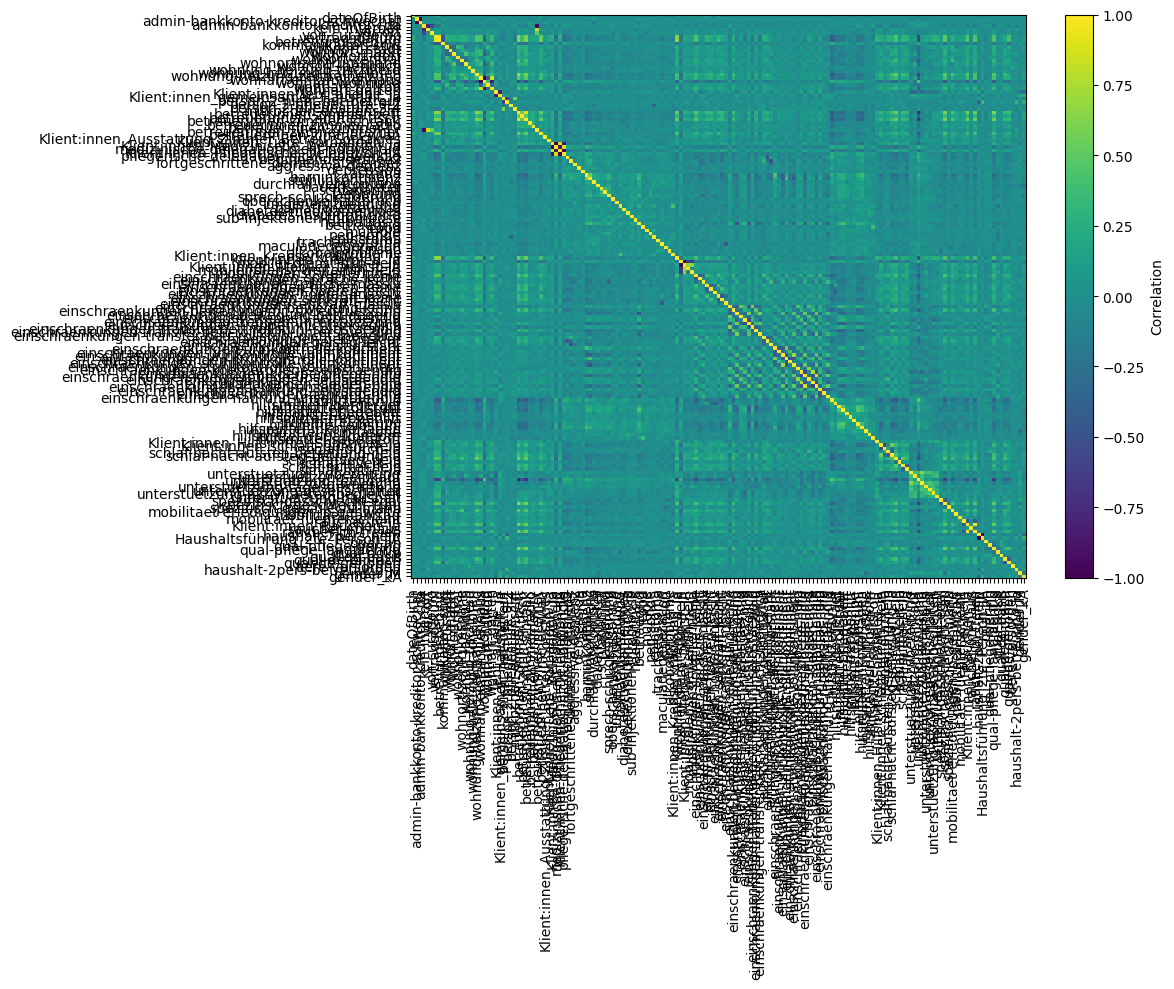

In [116]:
import matplotlib.pyplot as plt

corr = df.drop(columns=["id"]).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [117]:
def remove_correlated_features(df, threshold=0.8, exclude=["id"]):

    result = df.copy()
    dropped = []

    while True:

        features = result.drop(
            columns=exclude,
            errors="ignore"
        )

        corr = features.corr().abs()

        # Remove diagonal
        np.fill_diagonal(corr.values, 0)

        # Find strongest remaining correlation
        max_corr = corr.max().max()

        if max_corr <= threshold:
            break

        # Find the pair
        var1, var2 = corr.stack().idxmax()

        # Mean absolute correlation with all other variables
        score1 = corr.loc[var1].mean()
        score2 = corr.loc[var2].mean()

        # Drop the more redundant variable
        if score1 > score2:
            drop = var1
        else:
            drop = var2

        dropped.append({
            "dropped": drop,
            "var1": var1,
            "var2": var2,
            "pair_corr": max_corr,
            "score_var1": score1,
            "score_var2": score2
        })

        result = result.drop(columns=drop)

    return result, pd.DataFrame(dropped)

In [118]:
df_reduced, dropped = remove_correlated_features(
    df,
    threshold=0.8
)

print(dropped)

                                    dropped  \
0              admin-bankkonto-kreditor-cda   
1                   mobiler-dienst-hkp-nein   
2            Haushaltsführung_2te_Person_JA   
3   pflegerische-delegation-nicht-notwendig   
4   medizinische-delegation-nicht-notwendig   
5                           wohnart-wohnung   
6                   Klient:innen_Rauchen_Ja   
7                             kein-internet   
8                             vertragsdatum   
9                 betreuerinnen-zimmer-bett   
10  einschraenkungen-kleiden-unselbstaendig   
11  Klient:innen_Medizinische_Delegation_Ja   
12                  wohnart-einfamilienhaus   
13             Klient:innen_lebt_alleine_Ja   
14            betreuerinnen-zimmer-internet   

                                             var1  \
0              admin-bankkonto-kreditor-schwechat   
1                         mobiler-dienst-hkp-nein   
2                             haushalt-2pers-nein   
3         Klient:innen_Pflegerische

In [133]:
import gower


X = df_reduced.drop(
    columns=["id"],
    errors="ignore"
).copy()

# Convert all numeric columns to float
numeric_cols = X.select_dtypes(include=np.number).columns
X[numeric_cols] = X[numeric_cols].astype(float)

bool_cols = X.select_dtypes(include=["bool", "boolean"]).columns
X[bool_cols] = X[bool_cols].astype(float)

distance_matrix = gower.gower_matrix(X)

In [134]:
from sklearn_extra.cluster import KMedoids

models = {}

for k in range(2, 7):

    model = KMedoids(
        n_clusters=k,
        metric="precomputed",
        random_state=42
    )

    labels = model.fit_predict(distance_matrix)

    models[k] = {
        "model": model,
        "labels": labels
    }

c:\Users\Nicolas Pozdena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
c:\Users\Nicolas Pozdena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
c:\Users\Nicolas Pozdena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
c:\Users\Nicolas Pozdena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may 

In [135]:
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 7):

    model = KMedoids(
        n_clusters=k,
        metric="precomputed",
        random_state=42
    )

    labels = model.fit_predict(distance_matrix)

    silhouette = silhouette_score(
        distance_matrix,
        labels,
        metric="precomputed"
    )

    results.append({
        "k": k,
        "silhouette": silhouette,
        "inertia": model.inertia_
    })

results = pd.DataFrame(results)

print(results)

c:\Users\Nicolas Pozdena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [ ]:
best_k = results.loc[
    results["silhouette"].idxmax(),
    "k"
]

print("Best k:", best_k)

AttributeError: 'list' object has no attribute 'loc'

In [ ]:
final_model = KMedoids(
    n_clusters=int(best_k),
    metric="precomputed",
    random_state=42
)

df["client_class"] = final_model.fit_predict(
    distance_matrix
)

c:\Users\Nicolas Pozdena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
c:\Users\Nicolas Pozdena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
C:\Users\Nicolas Pozdena\AppData\Local\Temp\ipykernel_17316\1546182317.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["client_class"] = final_model.fit_predict(


In [ ]:
df["client_class"].value_counts()

client_class
0    10932
Name: count, dtype: int64

In [ ]:
profile = (
    df.drop(columns=["id"])
    .groupby("client_class")
    .mean()
    .T
)

print(profile)

client_class                        0           1           2
levelOfCare                  3.333333    3.857143    4.583333
kein-internet                0.750000    1.000000    1.000000
von-curadomo                 0.250000    0.000000    0.000000
kommunikaiton-sms            0.000000    0.000000    0.083333
pers-koerper-groesse       162.166667  164.571429  165.583333
...                               ...         ...         ...
paket_CD Perle               0.250000    0.142857    0.250000
paket_Demenzbetreuung        0.250000    0.000000    0.000000
paket_Klassik                0.083333    0.000000    0.333333
paket_Palliativbegleitung    0.083333    0.000000    0.000000
paket_Premium                0.333333    0.857143    0.333333

[149 rows x 3 columns]


In [ ]:
df

,id,levelOfCare,kein-internet,von-curadomo,kommunikaiton-sms,pers-koerper-groesse,pers-koerper-gewicht,wohnort-stadt,wohnort-markt,wohnort-dorf,...,mobiler-dienst-weiterhin-ja,zone_Zone 7,gender_M,gender_kA,paket_CD Perle,paket_Demenzbetreuung,paket_Klassik,paket_Palliativbegleitung,paket_Premium,client_class
0,ff9d5733-2744-fd9e-6984-7ccdb1142e53,4,1,0,0,165,63,0,1,0,...,0,0,0,0,0,0,1,0,0,2
1,dbc771e4-1ea9-4200-66a5-da613eea23c8,5,1,0,0,160,60,0,1,0,...,0,1,0,0,0,0,0,0,1,1
2,aaa424ab-8f46-29b9-8337-6523e1b1c201,4,1,0,0,160,50,1,0,0,...,0,1,0,0,1,0,0,0,0,2
3,39576f97-6341-2bc1-e088-a9e4776ebc56,1,1,0,0,180,80,1,0,0,...,0,1,1,0,0,0,1,0,0,0
4,0c6f8682-6674-b1fb-ad25-23145c0ced18,5,1,0,0,150,56,0,1,0,...,0,1,0,0,1,0,0,0,0,1
5,c34a2d44-a74a-fe43-3a1a-3d435c88d0ce,5,1,0,0,155,60,1,0,0,...,0,1,0,0,0,0,0,0,1,1
8,d1b82df9-8d3b-08c0-5b60-3963f7555434,1,1,0,0,171,48,0,1,0,...,0,0,0,0,0,0,0,0,1,1
9,8788f502-a202-d0eb-989a-1628ca74cee4,3,1,0,0,150,47,0,0,1,...,0,1,0,0,1,0,0,0,0,0
10,c8cbeb11-0417-a899-4d84-eeb28d5ef4be,2,0,1,0,160,65,1,0,0,...,0,1,0,0,0,0,0,0,1,0
13,b9fa8a8c-7b62-afa8-9dc1-6479a6973c24,3,1,0,0,167,58,1,0,0,...,0,1,0,1,0,0,0,0,1,0
